# EDA Phase for Individual Player Awards

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os


In [9]:
# Establishing file paths for loading and saving data
CLEANED_PATH = "../../data/cleaned"
PROCESSED_PATH = "../../data/processed"
os.makedirs(PROCESSED_PATH, exist_ok=True)

The first phase of EDA will be to determine what stat categories matter most for the MVP award. To do this, we'll break out the past MVP winners in a separate dataset and review their stats

In [10]:
# Importing the merged data set from notebook 01
players_df = pd.read_csv(f"{CLEANED_PATH}/player_all_years.csv")

In [11]:
# Previewing the data to ensure this is the correct DataFrame
players_df.head(5)

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,WS,WS/48,OBPM,DBPM,BPM,VORP,is_MVP,is_DPOY,is_PPG_Leader,Season
0,Kevin Durant,21.0,OKC,SF,82.0,82.0,39.5,9.7,20.3,0.476,...,16.1,0.238,6.3,0.8,7.1,7.5,False,False,True,2010
1,LeBron James,25.0,CLE,SF,76.0,76.0,39.0,10.1,20.1,0.503,...,18.5,0.299,9.1,2.8,11.8,10.3,True,False,False,2010
2,Carmelo Anthony,25.0,DEN,SF,69.0,69.0,38.2,10.0,21.8,0.458,...,7.9,0.145,3.5,-1.2,2.3,2.9,False,False,False,2010
3,Kobe Bryant,31.0,LAL,SG,73.0,73.0,38.8,9.8,21.5,0.456,...,9.4,0.160,3.9,0.2,4.1,4.4,False,False,False,2010
4,Dwyane Wade,28.0,MIA,SG,77.0,77.0,36.3,9.3,19.6,0.476,...,13.0,0.224,7.1,2.1,9.2,7.9,False,False,False,2010


In [ ]:
# Dropping other award columns
columns_to_drop = ["is_DPOY", "is_PPG_Leader"]
players_df.drop(columns=columns_to_drop, inplace=True)

In [12]:
# Setting MVP column to 0/1
players_df["is_MVP"] = players_df["is_MVP"].astype(int)

In [13]:
numeric_cols = players_df.select_dtypes(include=["number"]).columns
player_corr_matrix = players_df[numeric_cols].corr()

In [14]:
mvp_corr = player_corr_matrix["is_MVP"].drop("is_MVP").sort_values(ascending=False)
print(mvp_corr)

VORP      0.280380
OWS       0.223422
WS        0.206793
FT        0.155586
FTA       0.152654
PPG       0.135641
DWS       0.134099
FG        0.128268
2P        0.126246
TOV       0.125637
AST       0.122916
FGA       0.110419
2PA       0.108967
DRB       0.106168
PER       0.105017
AST%      0.104367
USG%      0.102877
BPM       0.092553
TRB       0.090750
OBPM      0.090195
STL       0.084232
GS        0.082106
WS/48     0.078890
MP        0.066367
3P        0.062389
3PA       0.060441
DBPM      0.056766
G         0.047123
DRB%      0.043720
BLK       0.040978
ORB       0.037948
TS%       0.036500
TRB%      0.032784
PF        0.030503
FG%       0.029621
eFG%      0.027503
2P%       0.027226
FTr       0.025304
FT%       0.021722
STL%      0.019877
3P%       0.016888
BLK%      0.006178
TOV%      0.001778
ORB%      0.000779
Age      -0.001706
Season   -0.003339
3PAr     -0.009380
Name: is_MVP, dtype: float64


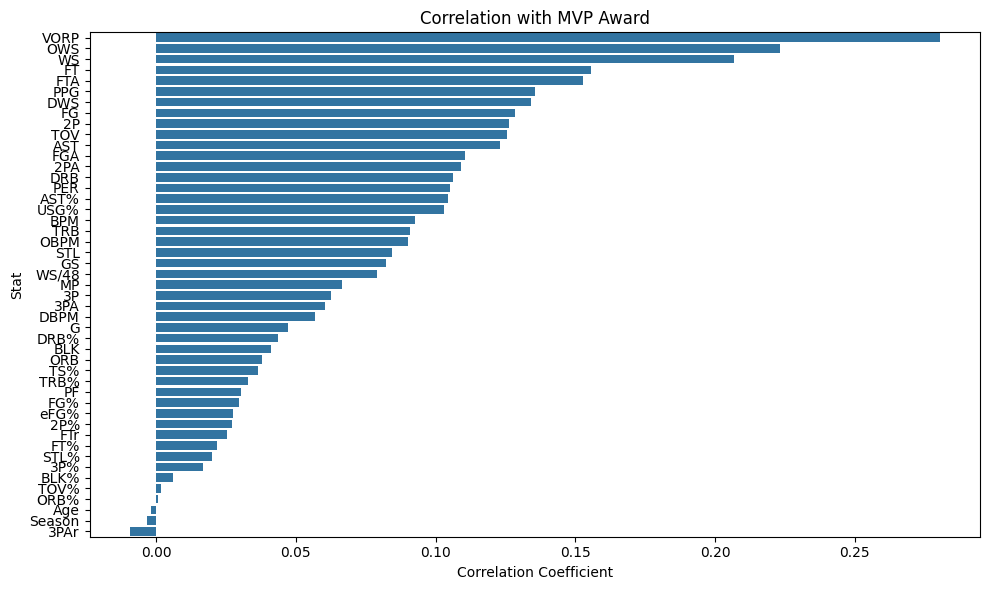

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(x=mvp_corr.values, y=mvp_corr.index)
plt.title("Correlation with MVP Award")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Stat")
plt.tight_layout()
plt.show()

Based on these results, we're going to take everything with a correlation of over .10 for further processing 

In [16]:
important_stats = mvp_corr[mvp_corr > 0.10].index

In [17]:
mvp_eda = players_df[list(important_stats) + ["is_MVP"]]

In [18]:
print(mvp_eda.head())
print(f"{mvp_eda.shape[1]-1} stats selected with correlation > 0.10")

   VORP   OWS    WS   FT   FTA   PPG  DWS    FG   2P  TOV  AST   FGA   2PA  \
0   7.5  11.1  16.1  9.2  10.2  30.1  5.0   9.7  8.1  3.3  2.8  20.3  16.1   
1  10.3  13.3  18.5  7.8  10.2  29.7  5.2  10.1  8.4  3.4  8.6  20.1  15.0   
2   2.9   5.6   7.9  7.4   8.9  28.2  2.4  10.0  9.1  3.0  3.2  21.8  19.1   
3   4.4   5.4   9.4  6.0   7.4  27.0  4.0   9.8  8.5  3.2  5.0  21.5  17.4   
4   7.9   8.5  13.0  6.9   9.1  26.6  4.6   9.3  8.4  3.3  6.5  19.6  16.5   

   DRB   PER  AST%  USG%  is_MVP  
0  6.3  26.2  13.5  32.0       0  
1  6.4  31.1  41.8  33.5       1  
2  4.4  22.2  15.9  33.4       0  
3  4.3  21.9  23.8  32.3       0  
4  3.5  28.0  36.4  34.9       0  
17 stats selected with correlation > 0.10


Now that we know the correlation between the most important stats and the MVP winners, we're going to look at correlation between these individual stats to reduce redudant features in the data.

In [19]:
# Creating a new dataframe for feature review
feature_corr = mvp_eda.drop(columns=["is_MVP"]).corr()

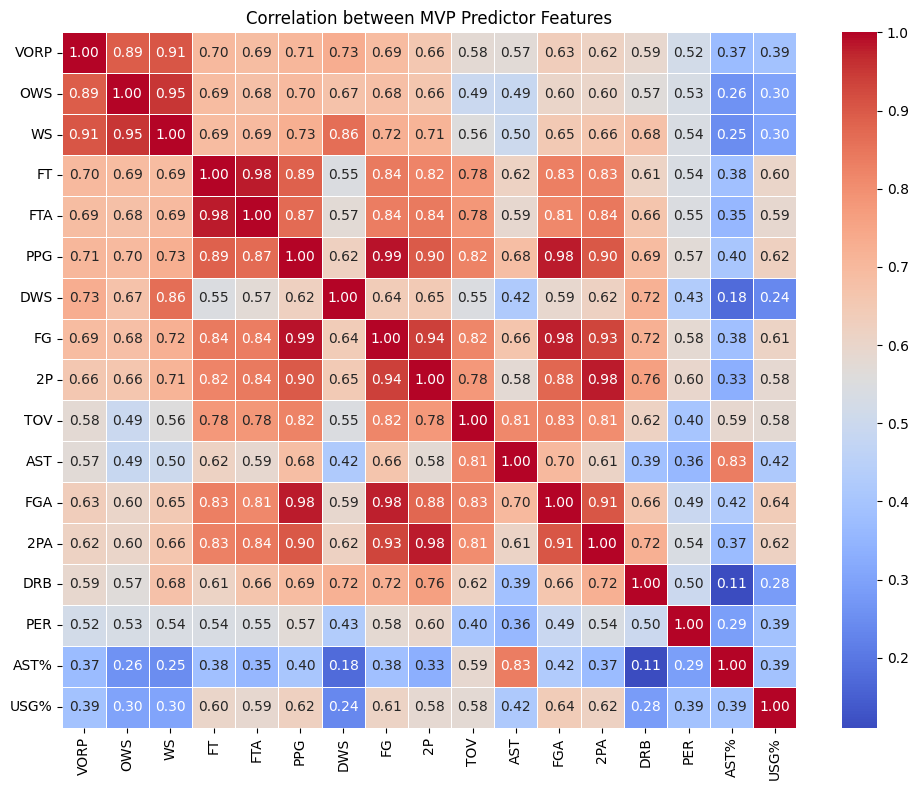

In [20]:
# Visualizing the data using a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(feature_corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation between MVP Predictor Features")
plt.tight_layout()
plt.show()

Looking at these results, there are a few columns that can be eliminted to avoid overfitting

In [21]:
# Creating a correlation matrix of absolute values
corr_matrix = mvp_eda.drop(columns=["is_MVP"]).corr().abs()

In [22]:
# Selecting the upper triangle to avoid duplicate pairs
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

In [23]:
# Finding highly correlated feature pairs (pairs over >.85)
high_corr_features = [
    column for column in upper.columns if any(upper[column] > 0.85)
]
print(f"Features to consider droppong due to high correlation: \n{high_corr_features}")

Features to consider droppong due to high correlation: 
['OWS', 'WS', 'FTA', 'PPG', 'DWS', 'FG', '2P', 'FGA', '2PA']


In [ ]:
# New DataFrame with reduced columns
reduced_df = mvp_eda.drop(columns=high_corr_features)

In [ ]:
# Reviewing the data
print(reduced_df.describe())
print(reduced_df.info())

              VORP           FT          TOV          AST          DRB  \
count  9716.000000  9716.000000  9716.000000  9716.000000  9716.000000   
mean      0.470214     1.316818     1.077367     1.807112     2.570564   
std       1.131812     1.310043     0.781233     1.763727     1.764112   
min      -2.000000     0.000000     0.000000     0.000000     0.000000   
25%      -0.100000     0.400000     0.500000     0.600000     1.300000   
50%       0.100000     0.900000     0.900000     1.200000     2.200000   
75%       0.700000     1.725000     1.400000     2.400000     3.400000   
max      10.600000    10.200000     5.700000    12.800000    12.000000   

               PER         AST%         USG%       is_MVP  
count  9714.000000  9714.000000  9714.000000  9716.000000  
mean     12.586267    12.939664    18.422740     0.001544  
std       6.668645     9.300225     5.644021     0.039263  
min     -45.200000     0.000000     0.000000     0.000000  
25%       9.500000     6.600000  

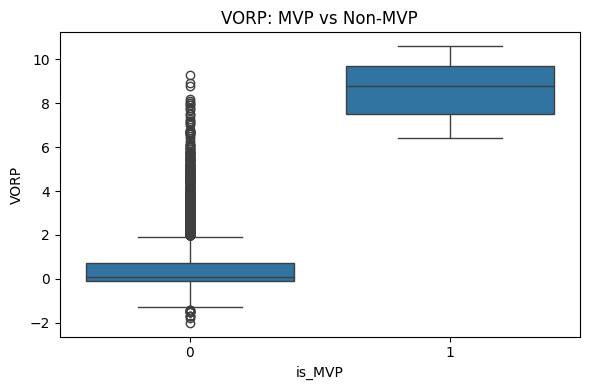

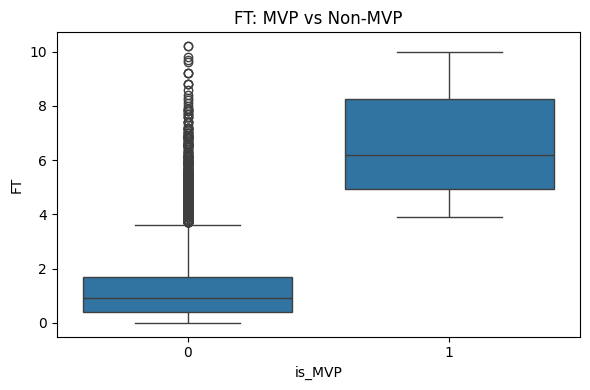

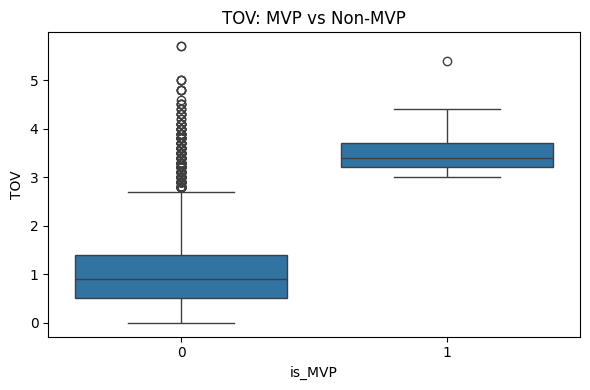

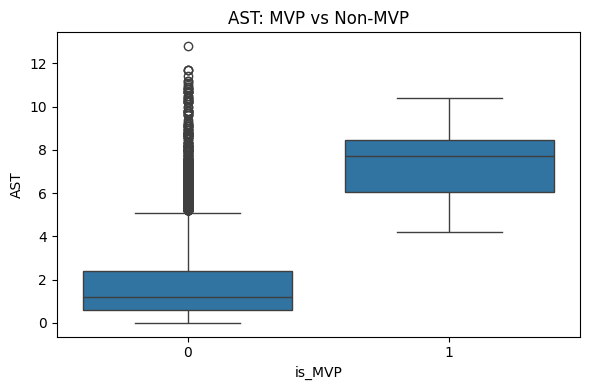

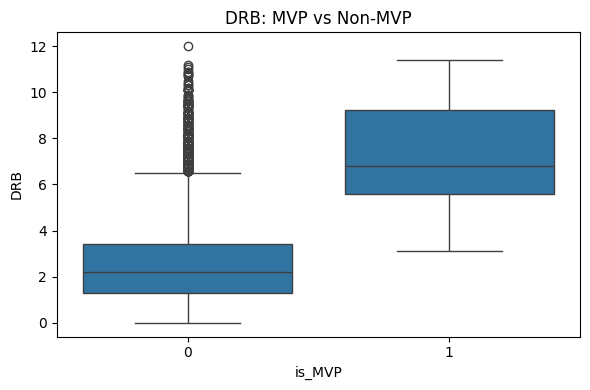

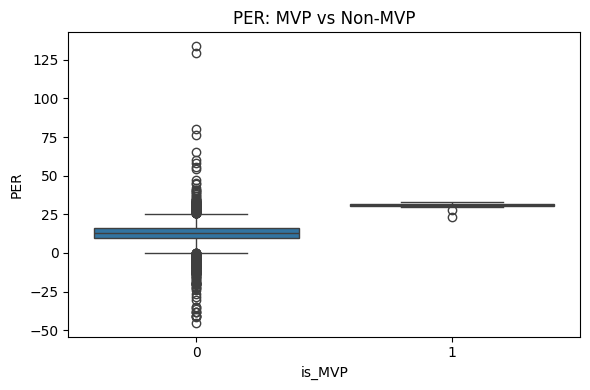

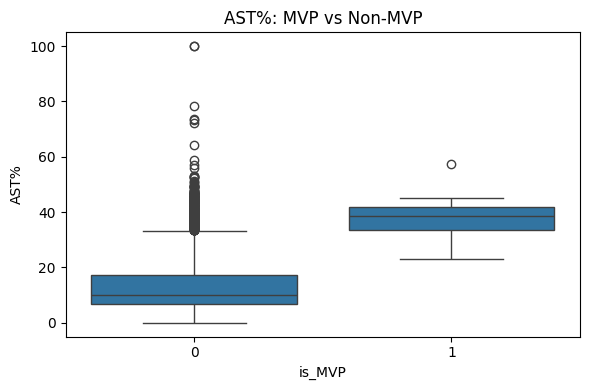

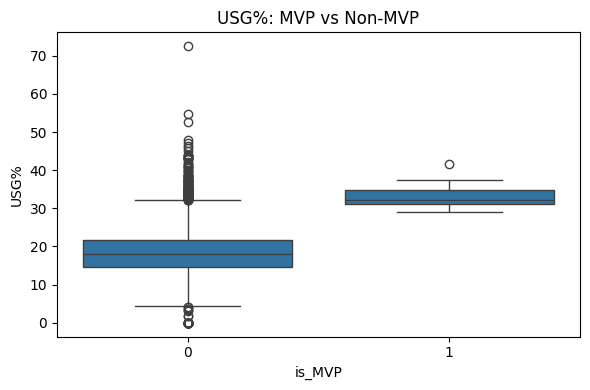

In [ ]:
# Visualizing MVP vs Non-MVP for Key Features (0 = Non-MVP, 1 = MVP)
for col in reduced_df.columns:
    if col != "is_MVP":
        plt.figure(figsize=(6,4))
        sns.boxplot(x="is_MVP", y=col, data=reduced_df)
        plt.title(f"{col}: MVP vs Non-MVP")
        plt.tight_layout()
        plt.show()

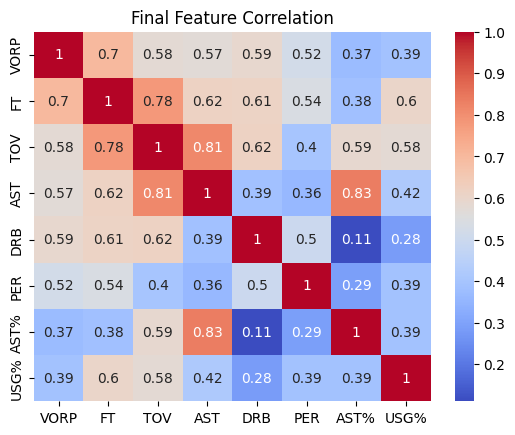

In [28]:
# One last check for redundancy
sns.heatmap(reduced_df.drop(columns="is_MVP").corr(), annot=True, cmap="coolwarm")
plt.title("Final Feature Correlation")
plt.show()

In [30]:
reduced_df.to_csv(f"{PROCESSED_PATH}/mvp_eda_cleaned.csv")
print(f"mvp_eda_cleaned saved to {PROCESSED_PATH}")

mvp_eda_cleaned saved to ../../data/processed
